In [1]:
!pip install tabpfn -q

import os

os.environ["TABPFN_TOKEN"] = "API_KEY"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tabpfn import TabPFNClassifier
import torch

In [3]:
# %% Cell 1 -- load and prepare data
train_df = pd.read_csv("/content/GSE98320.csv")
val_df   = pd.read_csv("/content/GSE129166.csv")

X_train = train_df.drop(columns=["sample_id", "diagnosis"])
y_train = train_df["diagnosis"]
X_val   = val_df.drop(columns=["sample_id", "diagnosis"])[X_train.columns]
y_val   = val_df["diagnosis"]

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns, index=X_val.index)

class_labels = sorted(y_train.unique())
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
# %% Cell 2 -- two model configurations to compare
def make_model_default():
    return TabPFNClassifier(device=device, random_state=42)

def make_model_tuned():
    return TabPFNClassifier(
        device=device,
        random_state=42,
        n_estimators=32,
        balance_probabilities=True,
        eval_metric="f1",
        tuning_config={
            "calibrate_temperature": True,
            "tune_decision_thresholds": True,
        },
    )

CONFIGS = {
    "TabPFN-Default": make_model_default,
    "TabPFN-Tuned": make_model_tuned,
}

In [5]:
# %% Cell 3 -- shared helper functions
def run_nested_cv(model_factory, name):
    outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    X_r, y_r = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
    oof_pred = np.empty(len(y_r), dtype=object)

    for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_r, y_r)):
        model = model_factory()
        model.fit(X_r.iloc[tr_idx], y_r.iloc[tr_idx])
        oof_pred[te_idx] = model.predict(X_r.iloc[te_idx])
        print(f"  [{name}] fold {fold + 1}/10 done")

    p, r, f, _ = precision_recall_fscore_support(y_r, oof_pred, labels=class_labels, zero_division=0)
    result = {
        "name": name, "stage": "CV",
        "accuracy": accuracy_score(y_r, oof_pred),
        "macro_precision": np.mean(p), "macro_recall": np.mean(r), "macro_f1": np.mean(f),
        "per_class_f1": dict(zip(class_labels, f)),
    }
    print_result(result)
    return result

def run_validation_no_tcmr(model_factory, name):
    model = model_factory()
    model.fit(X_train, y_train)

    val_mask = y_val != "TCMR"
    Xv, yv = X_val[val_mask], y_val[val_mask]
    val_labels = [c for c in class_labels if c != "TCMR"]
    print(f"  [{name}] excluded {(~val_mask).sum()} TCMR sample(s), evaluating on {len(yv)} samples")

    pred = model.predict(Xv)
    p, r, f, _ = precision_recall_fscore_support(yv, pred, labels=val_labels, zero_division=0)
    result = {
        "name": name, "stage": "Validation",
        "accuracy": accuracy_score(yv, pred),
        "macro_precision": np.mean(p), "macro_recall": np.mean(r), "macro_f1": np.mean(f),
        "per_class_f1": dict(zip(val_labels, f)),
    }
    print_result(result)
    return result

def print_result(result):
    print(f"\n=== {result['name']} — {result['stage']} ===")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print(f"Macro precision={result['macro_precision']:.4f}  "
          f"recall={result['macro_recall']:.4f}  f1={result['macro_f1']:.4f}")
    for cls, f1 in result["per_class_f1"].items():
        print(f"  {cls:6s} | f1={f1:.4f}")

In [6]:
# %% Cell 4 -- run both configs, CV + validation
results = {}
for name, factory in CONFIGS.items():
    print(f"\n########## {name} ##########")
    results[f"{name}_cv"] = run_nested_cv(factory, name)
    results[f"{name}_val"] = run_validation_no_tcmr(factory, name)


########## TabPFN-Default ##########


tabpfn-v3-classifier-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  213MB            

tabpfn-v3-classifier-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

  [TabPFN-Default] fold 1/10 done
  [TabPFN-Default] fold 2/10 done
  [TabPFN-Default] fold 3/10 done
  [TabPFN-Default] fold 4/10 done
  [TabPFN-Default] fold 5/10 done
  [TabPFN-Default] fold 6/10 done
  [TabPFN-Default] fold 7/10 done
  [TabPFN-Default] fold 8/10 done
  [TabPFN-Default] fold 9/10 done
  [TabPFN-Default] fold 10/10 done

=== TabPFN-Default — CV ===
Accuracy: 0.9153
Macro precision=0.8905  recall=0.8678  f1=0.8786
  ABMR   | f1=0.8703
  NR     | f1=0.9427
  TCMR   | f1=0.8228
  [TabPFN-Default] excluded 2 TCMR sample(s), evaluating on 75 samples

=== TabPFN-Default — Validation ===
Accuracy: 0.9733
Macro precision=0.9412  recall=0.9833  f1=0.9603
  ABMR   | f1=0.9375
  NR     | f1=0.9831

########## TabPFN-Tuned ##########
  [TabPFN-Tuned] fold 1/10 done
  [TabPFN-Tuned] fold 2/10 done
  [TabPFN-Tuned] fold 3/10 done
  [TabPFN-Tuned] fold 4/10 done
  [TabPFN-Tuned] fold 5/10 done
  [TabPFN-Tuned] fold 6/10 done
  [TabPFN-Tuned] fold 7/10 done
  [TabPFN-Tuned] fold 8/1

In [7]:
# %% Cell 5 -- comparison table
summary_rows = [results[k] for k in results]
summary_df = pd.DataFrame([
    {"name": r["name"], "stage": r["stage"], "accuracy": r["accuracy"],
     "macro_precision": r["macro_precision"], "macro_recall": r["macro_recall"],
     "macro_f1": r["macro_f1"]}
    for r in summary_rows
])
print("\n=== Comparison Table ===")
print(summary_df.to_string(index=False))
summary_df.to_csv("/content/tabpfn_default_vs_tuned.csv", index=False)


=== Comparison Table ===
          name      stage  accuracy  macro_precision  macro_recall  macro_f1
TabPFN-Default         CV  0.915326         0.890473      0.867797  0.878595
TabPFN-Default Validation  0.973333         0.941176      0.983333  0.960275
  TabPFN-Tuned         CV  0.917019         0.861735      0.908463  0.881264
  TabPFN-Tuned Validation  0.960000         0.941176      0.975000  0.955929


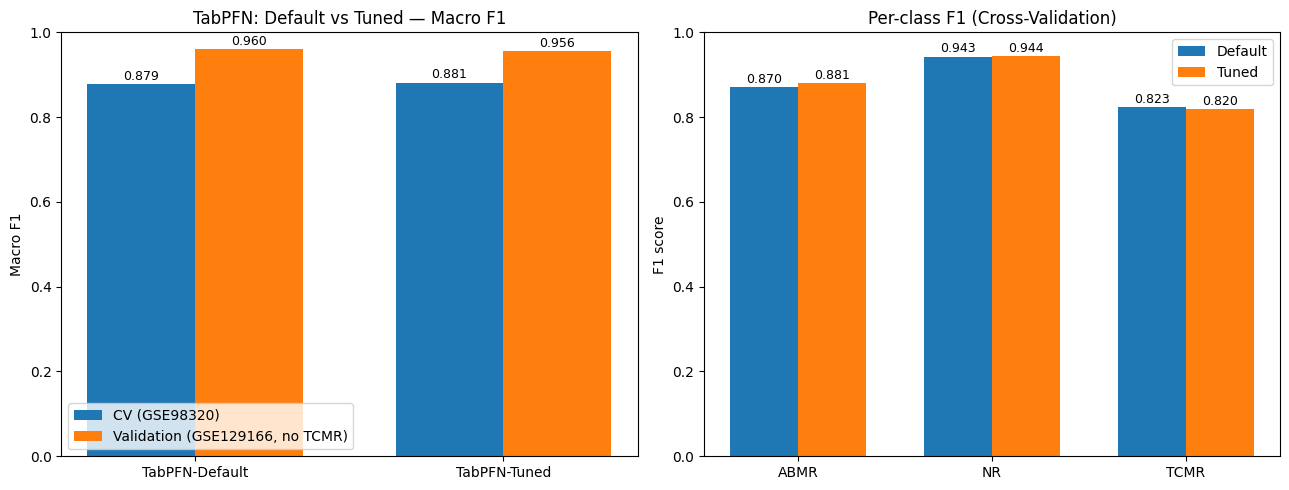


Saved: /content/tabpfn_default_vs_tuned.csv and /content/tabpfn_comparison.png


In [8]:
# %% Cell 6 -- comparison plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

configs_list = list(CONFIGS.keys())
cv_f1 = [results[f"{c}_cv"]["macro_f1"] for c in configs_list]
val_f1 = [results[f"{c}_val"]["macro_f1"] for c in configs_list]

x = np.arange(len(configs_list))
width = 0.35
axes[0].bar(x - width/2, cv_f1, width, label="CV (GSE98320)")
axes[0].bar(x + width/2, val_f1, width, label="Validation (GSE129166, no TCMR)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs_list)
axes[0].set_ylabel("Macro F1")
axes[0].set_ylim(0, 1)
axes[0].set_title("TabPFN: Default vs Tuned — Macro F1")
axes[0].legend()
for i, v in enumerate(cv_f1):
    axes[0].text(i - width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(val_f1):
    axes[0].text(i + width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

cv_default_classes = results[f"{configs_list[0]}_cv"]["per_class_f1"]
cv_tuned_classes = results[f"{configs_list[1]}_cv"]["per_class_f1"]
classes_present = sorted(set(cv_default_classes) | set(cv_tuned_classes))

x2 = np.arange(len(classes_present))
default_vals = [cv_default_classes.get(c, 0) for c in classes_present]
tuned_vals = [cv_tuned_classes.get(c, 0) for c in classes_present]
axes[1].bar(x2 - width/2, default_vals, width, label="Default")
axes[1].bar(x2 + width/2, tuned_vals, width, label="Tuned")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(classes_present)
axes[1].set_ylabel("F1 score")
axes[1].set_ylim(0, 1)
axes[1].set_title("Per-class F1 (Cross-Validation)")
axes[1].legend()
for i, v in enumerate(default_vals):
    axes[1].text(i - width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(tuned_vals):
    axes[1].text(i + width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/tabpfn_comparison.png", dpi=150)
plt.show()

print("\nSaved: /content/tabpfn_default_vs_tuned.csv and /content/tabpfn_comparison.png")